In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

# 1. Load real Kaggle/UCI CSV file
data = pd.read_csv("/content/diabetic_data.csv")

# 2. Map target variable: 1 if readmitted within 30 days (<30), else 0
data['readmitted_30d'] = data['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# 3. Select relevant clinical features and clean missing values
selected_columns = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'race', 'gender', 'age', 'readmitted_30d'
]

# Clean missing values marked as '?'
data = data[selected_columns].replace('?', np.nan).dropna()

print("Dataset Preview:")
display(data.head())

print("\nTarget Variable Distribution:")
print(data['readmitted_30d'].value_counts(normalize=True))

Dataset Preview:


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,race,gender,age,readmitted_30d
0,1,41.0,0.0,1.0,0.0,0.0,0.0,Caucasian,Female,[0-10),0
1,3,59.0,0.0,18.0,0.0,0.0,0.0,Caucasian,Female,[10-20),0
2,2,11.0,5.0,13.0,2.0,0.0,1.0,AfricanAmerican,Female,[20-30),0
3,2,44.0,1.0,16.0,0.0,0.0,0.0,Caucasian,Male,[30-40),0
4,1,51.0,0.0,8.0,0.0,0.0,0.0,Caucasian,Male,[40-50),0



Target Variable Distribution:
readmitted_30d
0    0.887512
1    0.112488
Name: proportion, dtype: float64


In [6]:
# Features and Target split
X = data.drop(columns=['readmitted_30d'])
y = data['readmitted_30d']

# Identify column types based on the real Kaggle diabetic_data.csv schema
numeric_features = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient'
]

categorical_features = ['race', 'gender', 'age']

# Construct ColumnTransformer for scaling and encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

# Train-Test Split (80/20) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Transform Data
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Retrieve transformed feature names
encoded_cat_names = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
feature_names = numeric_features + encoded_cat_names

print(f"Processed Training Shape: {X_train_proc.shape}")
print(f"Processed Testing Shape: {X_test_proc.shape}")

Processed Training Shape: (74006, 22)
Processed Testing Shape: (18502, 22)


In [7]:
# Instantiate Logistic Regression with L2 Regularization
# C=0.5 applies moderate penalty (smaller C = stronger regularization)
model = LogisticRegression(
    penalty='l2',
    C=0.5,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

# Fit model
model.fit(X_train_proc, y_train)

# Predict class probabilities and default labels
y_probs = model.predict_proba(X_test_proc)[:, 1]
y_pred_default = model.predict(X_test_proc)

print("Logistic Regression Model Trained Successfully.")

Logistic Regression Model Trained Successfully.


ROC-AUC Score: 0.6242



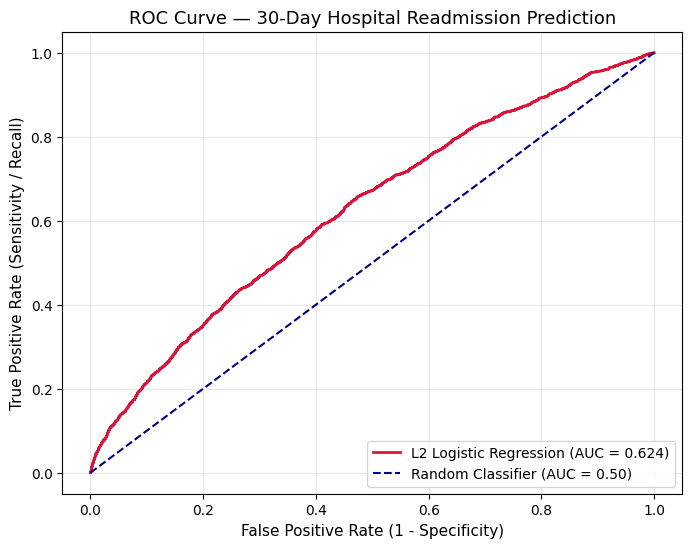

Default Threshold (0.5) Classification Metrics:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     16421
           1       0.42      0.01      0.03      2081

    accuracy                           0.89     18502
   macro avg       0.66      0.51      0.48     18502
weighted avg       0.84      0.89      0.84     18502



In [8]:
# Calculate ROC-AUC Score
auc_score = roc_auc_score(y_test, y_probs)
print(f"ROC-AUC Score: {auc_score:.4f}\n")

# Compute ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='crimson', lw=2, label=f'L2 Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('ROC Curve — 30-Day Hospital Readmission Prediction', fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# Classification Report at default 0.5 threshold
print("Default Threshold (0.5) Classification Metrics:")
print(classification_report(y_test, y_pred_default))

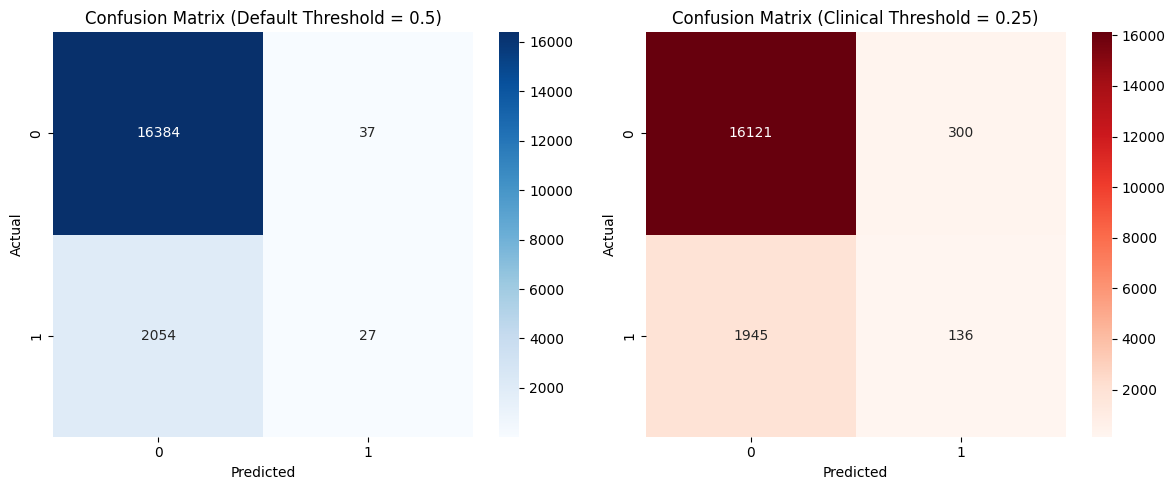

Default (0.50)  -> False Negatives: 2054 | False Positives: 37
Clinical (0.25) -> False Negatives: 1945 | False Positives: 300


In [9]:
# Evaluate threshold shift for clinical decision making
# Lowering threshold prioritizes minimizing False Negatives (unmonitored readmissions)

clinical_threshold = 0.25  # Decision threshold tuned for medical risk
y_pred_clinical = (y_probs >= clinical_threshold).astype(int)

cm_default = confusion_matrix(y_test, y_pred_default)
cm_clinical = confusion_matrix(y_test, y_pred_clinical)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Confusion Matrix (Default Threshold = 0.5)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_clinical, annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title(f"Confusion Matrix (Clinical Threshold = {clinical_threshold})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

fn_default = cm_default[1, 0]
fn_clinical = cm_clinical[1, 0]
fp_default = cm_default[0, 1]
fp_clinical = cm_clinical[0, 1]

print(f"Default (0.50)  -> False Negatives: {fn_default} | False Positives: {fp_default}")
print(f"Clinical ({clinical_threshold}) -> False Negatives: {fn_clinical} | False Positives: {fp_clinical}")